# SEE060: Lösning och rättningsmall för Inlämning 3

## Kod

In [1]:
import matplotlib.pyplot as plt
import numpy as np


START = 1990
END = 2300
INITIAL_MASS = 1e10  # kg
EMISSION = 4e8  # kg/year
RESIDENCE_TIME = 100  # year
ZERO_EMISSION_YEAR = 1996


def calc_mass(
    start_year, end_year, dt, initial_mass, emiss, year_zero_emiss, residence_time
):
    t = np.arange(start_year, end_year + dt, dt)
    mass = np.zeros_like(t)
    mass[0] = initial_mass

    for i, t_i in enumerate(t[:-1]):
        if t_i < year_zero_emiss:
            E = emiss
        else:
            E = 0

        mass[i + 1] = mass[i] + dt * (E - mass[i] / residence_time)

    return t, mass

## Fråga 1

### a) Visa att CFC-12 skulle uppnå jämvikt vid $m = 2 \cdot 10^{10}$ kg.

**Svar:**
Vid jämvikt är $\frac{dm}{dt} = 0$, vilket ger (från Ekvation (1)):

$$
0 = E - \frac{m}{\tau} \Rightarrow m = E\tau = 2 \cdot 10^{8} \cdot 100 = 2 \cdot 10^{10}~\text{kg}. 
$$

#### Rättningsmall

- Förklarar inte att dm/dt = 0 vid jämvikt.
  - Ge fel och kommentar 1.
 
##### Vanliga kommentarer

1. Rätt, men vi förväntar oss lite mer förklaringar, t.ex. att dm/dt = 0 gäller vid jämvikt.
2. Rätt, men vi förväntar oss lite mer förklaringar, t.ex. varför dm/dt ska vara 0.

### b) Detta är högre än massan 1989. Förklara hur detta kan ske?

**Svar:**
Eftersom utsläppstakten är större än nedbrytningstakten (p.g.a. den långa uppehållstiden) kommer massan freoner fortsätta öka.

#### Rättningsmall

- Säger att massan inte har nått jämvikt än.
  - Ge fel och kommentar 1.
- Säger att freoner inte hunnit brytas ner än eftersom uppehållstiden är 100 år.
  - Ge fel och kommentar 2.
- Säger att massan kommer öka så länge det finns utsläpp.
  - Ge fel och kommentar 3.
- Säger att det har med den långa uppehållstiden att göra, och att de gamla utsläppen fortfarande finns kvar.
  - Ge rätt och kommentar 4.
 
##### Vanliga kommentarer

1. Stämmer, men det förklarar inte varför jämviktsmassan är högre än massan år 1989 när utsläppen har minskat.
2. Du är inne på rätt spår. Notera dock att uppehållstiden anger ett medelvärde på livslängden - en del av freonerna bryts ner innan 100 år. Det handlar snarare om skillnaden mellan utsläppstakt och nedbrytningstakt. Om utsläppstakten är högre kommer massan fortsätta att öka.
3. Du är inne på rätt spår, men det beror även på utsläppstakten - om den är mindre än nedbrytningstakten (m/τ) kommer massan minska med tiden.
4. Delvis rätt, det har med den långa uppehållstiden att göra, men även med att utsläppstaken är större än nedbrytningstakten år 1989, vilket leder till att massan fortsätter öka.

### a) Skapa en plot som visar hur massan av CFC-12 varierar med tiden

**Svar:**

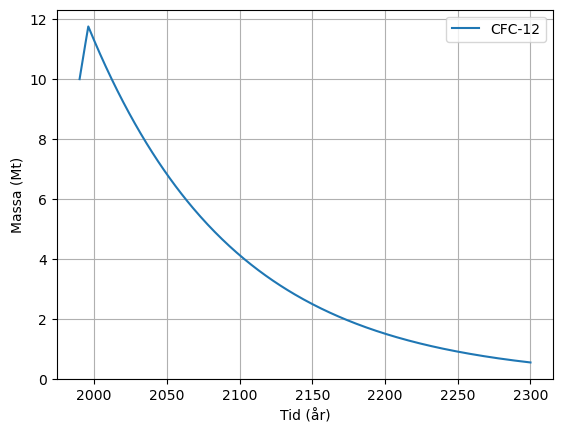

In [2]:
t, m = calc_mass(
    start_year=START,
    end_year=END,
    dt=1,
    initial_mass=INITIAL_MASS,
    emiss=EMISSION,
    year_zero_emiss=ZERO_EMISSION_YEAR,
    residence_time=RESIDENCE_TIME,
)
m = m/1e9  # Mt

fig, ax = plt.subplots()
ax.plot(t, m, label="CFC-12")
ax.set_ylabel("Massa (Mt)")
ax.set_xlabel("Tid (år)")
ax.grid()
ax.legend();

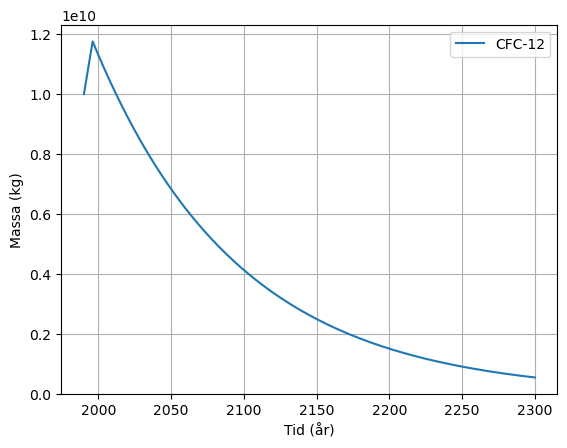

In [3]:
# Same graph in kg
fig, ax = plt.subplots()
ax.plot(t, m * 1e9, label="CFC-12")
ax.set_ylabel("Massa (kg)")
ax.set_xlabel("Tid (år)")
ax.grid()
ax.legend();

#### Rättningsmall

- Ingen enhet på y-axeln.
  - Ge fel och kommentar 1.

##### Vanliga kommentarer

1. Saknas enhet på y-axeln.

### b) Vad är den maximala massan av CFC-12 i atmosfären?

**Svar:** (automatiskt rättat)

In [13]:
print(f"Den maximala massan är {m.max():.2f} Mt.")

Den maximala massan är 11.76 Mt.


#### Rättningsmall

##### Vanliga kommentarer

1. Behöver inte ange så många decimaler (resultatet här är inte så exakt).

### c) Vilket år försvinner ozonhålet?

**Svar:** (automatiskt rättat)

In [5]:
year_ozone_hole = t[m < 7][0]
print(f"Ozonhålet försvinner år {year_ozone_hole}.")

Ozonhålet försvinner år 2048.


### d) Vilket år är CFC-12 borta ur atmosfären?

**Svar:** (automatiskt rättat)

In [6]:
year_cfc_gone = t[m < 1][0]
print(f"CFC-12 är borta ur atmosfären år {year_cfc_gone}.")

CFC-12 är borta ur atmosfären år 2242.


## Fråga 3

### a) Skapa en plot som visar hur massan av CFC-12 varierar med tiden

**Svar:**

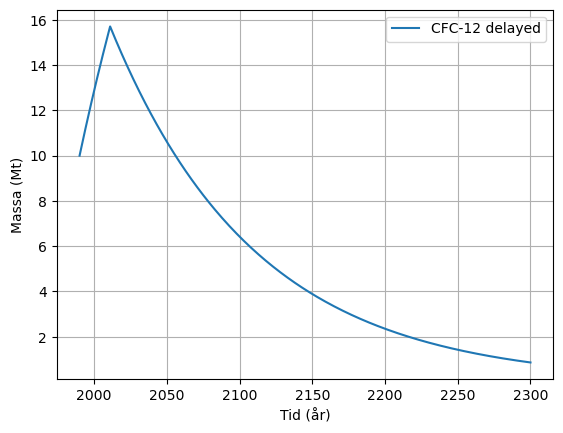

In [7]:
t_delayed, m_delayed = calc_mass(
    start_year=START,
    end_year=END,
    dt=1,
    initial_mass=INITIAL_MASS,
    emiss=EMISSION,
    year_zero_emiss=ZERO_EMISSION_YEAR + 15,
    residence_time=RESIDENCE_TIME,
)
m_delayed = m_delayed/1e9  # Mt

fig, ax = plt.subplots()
ax.plot(t_delayed, m_delayed, label="CFC-12 delayed")
#ax.plot(t, m, 'k--', label="CFC-12 reference")
ax.set_ylabel("Massa (Mt)")
ax.set_xlabel("Tid (år)")
ax.grid()
ax.legend();

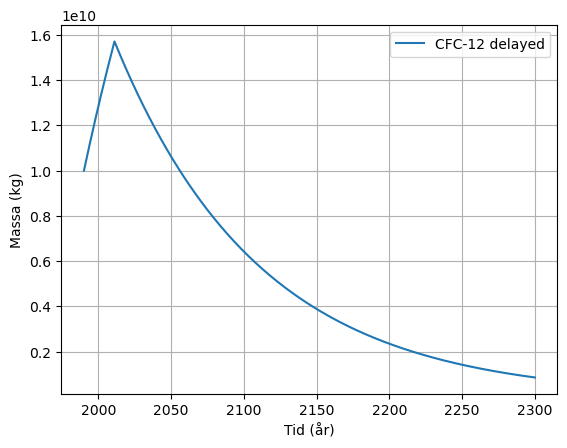

In [8]:
# Same graph in kg
fig, ax = plt.subplots()
ax.plot(t_delayed, m_delayed * 1e9, label="CFC-12 delayed")
#ax.plot(t, m * 1e9, 'k--', label="CFC-12 reference")
ax.set_ylabel("Massa (kg)")
ax.set_xlabel("Tid (år)")
ax.grid()
ax.legend();

#### Rättningsmall

- Ingen enhet på y-axeln.
  - Ge fel och kommentar 1.

##### Vanliga kommentarer

1. Saknas enhet på y-axeln.

### b) Vad är den maximala massan av CFC-12 i atmosfären?

**Svar:** (automatiskt rättat)

In [9]:
print(f"Den maximala massan är {m_delayed.max():.2f} Mt.")

Den maximala massan är 15.71 Mt.


### c) Vilket år försvinner ozonhålet?

**Svar:** (automatiskt rättat)

In [10]:
year_ozone_hole_delayed = t_delayed[m_delayed < 7][0]
print(f"Ozonhålet försvinner år {year_ozone_hole_delayed}.")

Ozonhålet försvinner år 2092.


### d) Vilket år är CFC-12 borta ur atmosfären?

**Svar:** (automatiskt rättat)

In [11]:
year_cfc_gone_delayed = t_delayed[m_delayed < 1][0]
print(f"CFC-12 är borta ur atmosfären år {year_cfc_gone_delayed}.")

CFC-12 är borta ur atmosfären år 2286.


### e) Vilken effekt hade en försening av Montrealprotokollet på 15 år fått?

**Svar:**
En 15-årig försening av Montrealprotokollet hade lett till en 44 års fördröjning innan ozonhålet försvinner och CFC-12 är borta ur atmosfären.
Dessutom hade den högsta halten av CFC-12 i atmosfären varit nästan 4 Mt högre (34% högre jämfört med utan fördröjning).

In [12]:
print(f"Difference in peak concentration: {m_delayed.max() - m.max():.2f} Mt.")
print(f"Relative difference in peak concentration: {(m_delayed.max() - m.max())/m.max() * 100:.2f}%.")
print(f"Ozone hole delay: {year_ozone_hole_delayed - year_ozone_hole} years.")
print(f"CFC-12 gone delay: {year_cfc_gone_delayed - year_cfc_gone} years.")

Difference in peak concentration: 3.95 Mt.
Relative difference in peak concentration: 33.62%.
Ozone hole delay: 44 years.
CFC-12 gone delay: 44 years.


#### Rättningsmall

- Anger inte exakt hur stora effekter/fördröjningar.
  - Ge fel och kommentar.

##### Vanliga kommentarer

1. Du kan kvantifiera hur stora skadar (hur större massa freoner?) och hur mycket längre tid för ozonhålet att försvinna/CFC-12 att vara borta ur atmosfären vid en fördröjning.
2. Med dina resultat kan du kvantifiera vad "betydligt längre tid" hade inneburit i det här fallet.
3. Med dina resultat kan du ge mer konkreta siffror på hur mycket det hade påverkat massan av CFC-12 i atmosfären och återhämtningstiden.